In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

In [4]:
ticker = "AAPL"
start_date = "2010-01-01"

data = yf.download(ticker, start=start_date,auto_adjust=False)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
data.columns.name = None
data.index.name = "Date"  # optional, makes the index column named when saving
data_dir = Path("/content/drive/MyDrive/datascience/apple")
data_dir.mkdir(parents=True, exist_ok=True)
data.to_csv(data_dir / "AAPL_raw.csv") # saves from having to load again

[*********************100%***********************]  1 of 1 completed


data checks

In [5]:
data.head()


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2010-01-04,6.406481,7.643214,7.660714,7.585000,7.622500,493729600
2010-01-05,6.417555,7.656429,7.699643,7.616071,7.664286,601904800
2010-01-06,6.315476,7.534643,7.686786,7.526786,7.656429,552160000
2010-01-07,6.303802,7.520714,7.571429,7.466071,7.562500,477131200
2010-01-08,6.345711,7.570714,7.571429,7.466429,7.510714,447610800


In [6]:
data.tail()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-06-18,298.010010,298.010010,300.570007,295.619995,298.109985,85962200
2026-06-22,297.010010,297.010010,302.420013,296.760010,297.309998,44879900
2026-06-23,294.299988,294.299988,301.640015,294.179993,297.540009,52010900
2026-06-24,293.079987,293.079987,299.700012,292.940002,295.359985,52882100
2026-06-25,279.815002,279.815002,288.799988,277.459991,287.510010,23399444


In [7]:
rows, cols = data.shape
print(f"Rows: {rows}, Columns: {cols}")
data.info()
data.index.is_monotonic_increasing

Rows: 4144, Columns: 6
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4144 entries, 2010-01-04 to 2026-06-25
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  4144 non-null   float64
 1   Close      4144 non-null   float64
 2   High       4144 non-null   float64
 3   Low        4144 non-null   float64
 4   Open       4144 non-null   float64
 5   Volume     4144 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 226.6 KB


True

In [8]:
data.isna().sum()

,0
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [9]:
first_date  = data.index.min()
last_date   = data.index.max()
n_records   = len(data)
any_missing = data.isna().any().any()

print("First date:", first_date)
print("Latest date:", last_date)
print("Number of trading-day records:", n_records)
print("Any missing values:", any_missing)

# Example difference between opening and closing prices (can also take mean)
data["Close_minus_Open"] = data["Close"] - data["Open"]
print(data["Close_minus_Open"].head())
print("Mean difference between close and open prices",data['Close_minus_Open'].mean())

First date: 2010-01-04 00:00:00
Latest date: 2026-06-25 00:00:00
Number of trading-day records: 4144
Any missing values: False
Date
2010-01-04    0.020714
2010-01-05   -0.007857
2010-01-06   -0.121786
2010-01-07   -0.041786
2010-01-08    0.060000
Name: Close_minus_Open, dtype: float64
Mean difference between close and open prices 0.06121141949675718


# Exploratory Data Analysis

In [10]:
# 1. Daily percentage return (using close prices)
data["Daily_Return"] = data["Close"].pct_change()

# 2. Price and volume summary statistics
min_close    = data["Close"].min()
max_close    = data["Close"].max()
avg_close    = data["Close"].mean()
median_close = data["Close"].median()
avg_volume   = data["Volume"].mean()
avg_daily_ret = data["Daily_Return"].mean()

print("Minimum closing price:", min_close)
print("Maximum closing price:", max_close)
print("Average closing price:", avg_close)
print("Median closing price:", median_close)
print("Average daily trading volume:", avg_volume)
print("Average daily return:", avg_daily_ret)

Minimum closing price: 6.85892915725708
Maximum closing price: 315.20001220703125
Average closing price: 85.44776162378577
Median closing price: 42.88999938964844
Average daily trading volume: 214044511.59362933
Average daily return: 0.0010258412407425708


In [11]:
# Absolute daily moves
data["Abs_Daily_Return"] = data["Daily_Return"].abs()

# Top 1% largest absolute returns
threshold_ret = data["Abs_Daily_Return"].quantile(0.99)
big_moves = data[data["Abs_Daily_Return"] >= threshold_ret]

# Top 1% largest volumes
threshold_vol = data["Volume"].quantile(0.99)
big_volume_days = data[data["Volume"] >= threshold_vol]

print("Number of very large move days (top 1%):", len(big_moves))
print("Number of very high volume days (top 1%):", len(big_volume_days))

Number of very large move days (top 1%): 42
Number of very high volume days (top 1%): 42


In [12]:
big_moves[["Close", "Daily_Return", "Volume"]]


,Close,Daily_Return,Volume
Date,,,
2010-04-21,9.257857,0.059814,982391200
2010-05-10,9.071071,0.076868,984306400
2012-01-25,15.952143,0.062439,958314000
2012-04-25,21.785713,0.088741,905777600
2012-11-19,20.204643,0.072108,823317600
2012-12-05,19.242500,-0.064357,1044638000
2013-01-24,16.089287,-0.123558,1460852400
2014-01-28,18.089287,-0.079927,1065523200
2014-04-24,20.277500,0.081982,759911600


In [13]:
big_volume_days[["Close", "Daily_Return", "Volume"]]

,Close,Daily_Return,Volume
Date,,,
2010-01-25,7.252500,0.026903,1065699600
2010-01-26,7.355000,0.014133,1867110000
2010-01-27,7.424286,0.009420,1722568400
2010-01-28,7.117500,-0.041322,1173502400
2010-01-29,6.859286,-0.036279,1245952400
2010-05-06,8.794643,-0.038048,1285860800
2010-05-07,8.423571,-0.042193,1676018400
2010-05-19,8.869286,-0.015930,1025726800
2010-05-20,8.491429,-0.042603,1282915200


Apple’s closing price in this sample ranges from about 6.86 at the low end to about 315.20 at the high end, showing how much the stock has grown over the period. The average closing price is roughly 85.40, while the median is around 42.88, which suggests that many of the earlier observations are clustered at lower price levels and later years bring much higher prices.

Average daily trading volume is about 214 million shares, indicating very high liquidity and constant investor activity in Apple’s stock. The average daily return is approximately 0.10%, so on a typical trading day the price tends to move slightly upward, though the effect is small at the daily scale.

There are 42 days in the top 1% of absolute daily returns and 42 days in the top 1% of trading volume. This shows that a relatively small number of days experience unusually large price moves and unusually heavy trading, which likely correspond to major events such as earnings announcements.

It is also worth noting that big‑move days are spread fairly evenly across the years, which means large percentage price changes occur throughout the sample rather than being concentrated in one early “high‑risk” period. In contrast, unusually high‑volume days appear only up to early 2014, suggesting that trading activity later became more stable or structurally different, so volatility in recent years is less often accompanied by extreme volume spikes.

# Visualisation

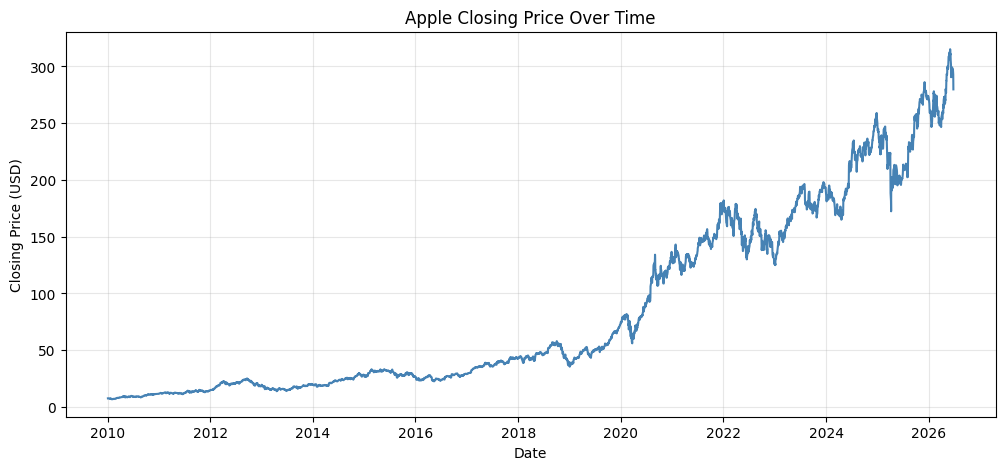

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(data.index, data["Close"], color="steelblue")
plt.title("Apple Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.grid(alpha=0.3)
plt.show()

Apple’s closing price shows a clear long‑term upward trend, rising from single‑digit levels in the early part of the sample to well above 300 USD at its peak. There are several drawdown periods, but the overall direction over 2010–present is strongly positive.

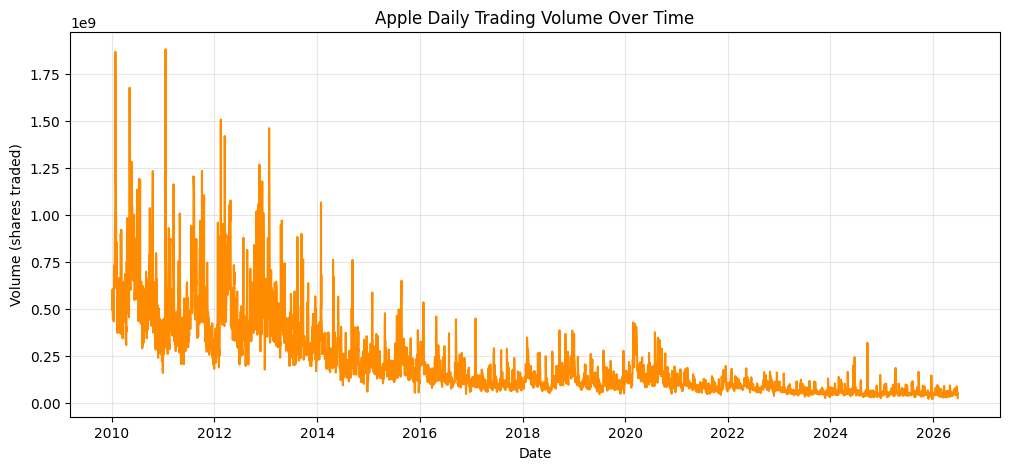

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(data.index, data["Volume"], color="darkorange")
plt.title("Apple Daily Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume (shares traded)")
plt.grid(alpha=0.3)
plt.show()

Daily trading volume is consistently high, but the largest volume spikes occur mainly in the earlier years up to around 2015. After that, volume appears more stable, suggesting that extreme bursts of trading activity became less frequent or changed in structure over time.

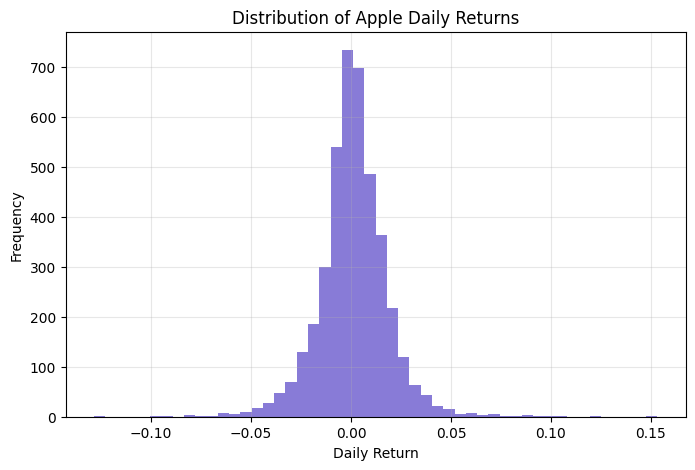

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(data["Daily_Return"].dropna(), bins=50, color="slateblue", alpha=0.8)
plt.title("Distribution of Apple Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

The distribution of Apple’s daily returns is sharply peaked around zero and decays quickly on both sides, which looks close to a bell‑shaped, approximately normal distribution. There are a few larger positive and negative moves, but extreme return days are relatively rare compared with the large number of small daily changes.

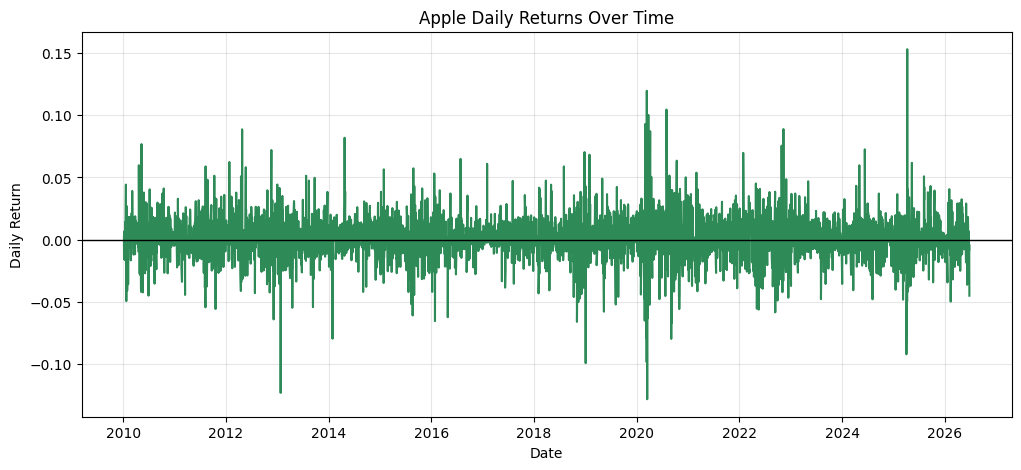

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(data.index, data["Daily_Return"], color="seagreen")
plt.title("Apple Daily Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.axhline(0, color="black", linewidth=1)
plt.grid(alpha=0.3)
plt.show()

The daily‑return series fluctuates around zero with periods where the spikes become much larger, indicating higher volatility. These more volatile episodes correspond to clusters of large positive and negative returns, while calmer periods show smaller, tightly‑grouped movements. Noticeably, there is some high fluctuation around 2020, coinciding with Covid-19.

# Feature Engineering

In [18]:
#Daily, 2-day, 5-day and 10-day returns
data["ret_1d"] = data["Close"].pct_change(1)
data["ret_2d"]  = data["Close"].pct_change(2)
data["ret_5d"]  = data["Close"].pct_change(5)
data["ret_10d"] = data["Close"].pct_change(10)


In [19]:
# 5-day, 20-day and 50-day moving average
data["ma_5"]  = data["Close"].rolling(window=5).mean()
data["ma_20"] = data["Close"].rolling(window=20).mean()
data["ma_50"] = data["Close"].rolling(window=50).mean()

In [20]:
# Price‑to‑moving‑average relationships
data["rel_ma_5"]  = (data["Close"] - data["ma_5"])  / data["ma_5"]
data["rel_ma_20"] = (data["Close"] - data["ma_20"]) / data["ma_20"]
data["rel_ma_50"] = (data["Close"] - data["ma_50"]) / data["ma_50"]

In [21]:
data["vol_change_1d"] = data["Volume"].pct_change(1)

In [22]:
data["vol_ma_20"]    = data["Volume"].rolling(window=20).mean()
data["rel_vol_20"]   = (data["Volume"] - data["vol_ma_20"]) / data["vol_ma_20"]

In [23]:
data["vol_5"]  = data["ret_1d"].rolling(window=5).std()
data["vol_10"] = data["ret_1d"].rolling(window=10).std()
data["vol_20"] = data["ret_1d"].rolling(window=20).std()

In [24]:
window = 14

delta = data["Close"].diff()

gain = delta.where(delta > 0, 0.0)
loss = -delta.where(delta < 0, 0.0)

avg_gain = gain.rolling(window=window).mean()
avg_loss = loss.rolling(window=window).mean()

rs = avg_gain / (avg_loss + 1e-8)
data["RSI_14"] = 100 - (100 / (1 + rs))

In [25]:
# Tomorrow's closing price (shifted up one row)
data["Close_next"] = data["Close"].shift(-1)

# Binary target: 1 if tomorrow's close > today's close, else 0
data["target"] = (data["Close_next"] > data["Close"]).astype(int)

In [26]:
target_counts = data["target"].value_counts(dropna=True)
print(target_counts)
print("\nClass proportions:\n", target_counts / target_counts.sum())

target
1    2191
0    1953
Name: count, dtype: int64

Class proportions:
 target
1    0.528716
0    0.471284
Name: count, dtype: float64


Class 1 (days when Apple’s closing price goes up the next day) appears 2,191 times, which is about 52.9% of all observations.

Class 0 (days when the price is flat or down the next day) appears 1,952 times, around 47.1% of the data.

This means the dataset is only mildly imbalanced: upward days are somewhat more common than non‑upward days, but both classes are well represented, so the model has enough examples of each to learn from.

In [27]:
feature_list = [
    "ret_1d",
    "ret_2d",
    "ret_5d",
    "ret_10d",
    "rel_ma_5",
    "rel_ma_20",
    "rel_ma_50",
    "vol_change_1d",
    "vol_5",
    "vol_10",
    "vol_20",
    "RSI_14",
]

In [ ]:
import

In [28]:
model_data = data.copy()


model_data[feature_list] = model_data[feature_list].replace([np.inf, -np.inf], np.nan)

model_data = model_data.dropna(subset=feature_list + ["target"])

print("Modelling dataset rows:", len(model_data))

Modelling dataset rows: 4095


In [29]:
X = model_data[feature_list].values
y = model_data["target"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4095, 12)
y shape: (4095,)


In [30]:
# Ensure chronological order
model_data = model_data.sort_index()

n = len(model_data)
split_idx = int(0.8 * n)

train_data = model_data.iloc[:split_idx]
test_data  = model_data.iloc[split_idx:]

X_train = train_data[feature_list].values
y_train = train_data["target"].values

X_test  = test_data[feature_list].values
y_test  = test_data["target"].values

train_start, train_end = train_data.index.min(), train_data.index.max()
test_start,  test_end  = test_data.index.min(),  test_data.index.max()
dates_train = train_data.index
dates_test  = test_data.index

print("Train period:", train_start, "to", train_end)
print("Test period:", test_start, "to", test_end)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train period: 2010-03-16 00:00:00 to 2023-03-20 00:00:00
Test period: 2023-03-21 00:00:00 to 2026-06-25 00:00:00
Train shape: (3276, 12) Test shape: (819, 12)


In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [32]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=5000, random_state=0,solver='liblinear')

# Train on the scaled training data
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000, random_state=0, solver='liblinear')

In [33]:
# Predicted classes (0 or 1)
y_pred = log_reg.predict(X_test_scaled)

# Predicted probability of class 1 (price going up)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

In [34]:
results = pd.DataFrame({
    "Date": dates_test,
    "Actual": y_test,
    "Predicted": y_pred,
    "Prob_up": y_proba,
})

results["Correct"] = (results["Actual"] == results["Predicted"]).astype(int)

# Optional: sort by date if needed
results = results.sort_values("Date")

results.head()

,Date,Actual,Predicted,Prob_up,Correct
0,2023-03-21,0,1,0.545739,0
1,2023-03-22,1,1,0.563438,1
2,2023-03-23,1,1,0.523668,1
3,2023-03-24,0,1,0.533507,0
4,2023-03-27,0,1,0.546495,0


In [35]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

# Core metrics
acc       = accuracy_score(y_test, y_pred)
bal_acc   = balanced_accuracy_score(y_test, y_pred)
prec      = precision_score(y_test, y_pred)  # for class 1 by default
rec       = recall_score(y_test, y_pred)     # for class 1 by default
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_proba)

cm        = confusion_matrix(y_test, y_pred)
report    = classification_report(y_test, y_pred)

print("Accuracy:", acc)
print("Balanced accuracy:", bal_acc)
print("Precision (class 1):", prec)
print("Recall (class 1):", rec)
print("F1 score:", f1)
print("ROC-AUC:", roc_auc)
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", report)

Accuracy: 0.5201465201465202
Balanced accuracy: 0.4924439515645606
Precision (class 1): 0.5317679558011049
Recall (class 1): 0.876993166287016
F1 score: 0.6620808254514188
ROC-AUC: 0.45663589497662144

Confusion matrix:
 [[ 41 339]
 [ 54 385]]

Classification report:
               precision    recall  f1-score   support

           0       0.43      0.11      0.17       380
           1       0.53      0.88      0.66       439

    accuracy                           0.52       819
   macro avg       0.48      0.49      0.42       819
weighted avg       0.49      0.52      0.43       819



In [36]:
from sklearn.model_selection import GridSearchCV

In [37]:
from sklearn.pipeline import Pipeline

In [48]:
pipeline=Pipeline(steps=[('scaler',StandardScaler()),('classifier',LogisticRegression(max_iter=10000,random_state=42,solver='liblinear'))])

In [58]:
parameter_grid={'classifier__C':[0.001,0.01,0.1,1,10,100,1000],'classifier__penalty':['l1','l2']}
grid_search=GridSearchCV(pipeline,param_grid=parameter_grid,cv=10,scoring='accuracy')

In [59]:
grid_search.fit(X_train_scaled,y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('classifier',
                                        LogisticRegression(max_iter=10000,
                                                           random_state=42,
                                                           solver='liblinear'))]),
             param_grid={'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'classifier__penalty': ['l1', 'l2']},
             scoring='accuracy')

In [60]:
grid_search.best_estimator_

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(C=1, max_iter=10000, random_state=42,
                                    solver='liblinear'))])

In [61]:
grid_search.best_params_

{'classifier__C': 1, 'classifier__penalty': 'l2'}

In [62]:
grid_search.best_score_

np.float64(0.5216808383680166)